step1: Prepare environment & import libraries

In [1]:
# ------------------------------
# 1) SETUP & IMPORTS
# ------------------------------
# Install any missing packages before running:
# pip install pandas scikit-learn joblib shap fastapi uvicorn

import pandas as pd
import numpy as np
import joblib

# sklearn imports
from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# for reproducibility
RND = 42


step2: Load data
> Add blockquote



In [2]:
# ------------------------------
# 2) LOAD DATA & BASIC INSPECTION
# ------------------------------
# Replace 'cleaned_dataset_Thyroid1.csv' with your actual file path.
df = pd.read_csv('cleaned_dataset_Thyroid1.csv')

In [3]:
# ------------------------------
# STEP 3: SPLIT FEATURES & LABEL
# ------------------------------
X = df.drop(columns=['binaryClass'])
y = df['binaryClass']

print("Feature shape:", X.shape)
print("Label distribution:\n", y.value_counts(normalize=True))


Feature shape: (3771, 25)
Label distribution:
 binaryClass
0    0.922832
1    0.077168
Name: proportion, dtype: float64


In [4]:
# ------------------------------
# STEP 4: TRAIN/TEST SPLIT
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3016, 25)  Test: (755, 25)


In [5]:
# ------------------------------
# STEP 5: PREPROCESSING + PIPELINE
# ------------------------------

# Identify numeric vs binary/categorical
num_features = ['age','TSH','TT4','T4U','FTI']
bin_features = [c for c in X.columns if c not in num_features]

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Preprocessor
preproc = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('bin', 'passthrough', bin_features)
])

# Full pipeline with classifier
pipeline = Pipeline([
    ('prep', preproc),
    ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42))
])


In [6]:
# ------------------------------
# STEP 6:------------------------
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [7]:
# ------------------------------
# STEP 7: EVALUATION
# ------------------------------
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9971    0.9986       697
           1     0.9667    1.0000    0.9831        58

    accuracy                         0.9974       755
   macro avg     0.9833    0.9986    0.9908       755
weighted avg     0.9974    0.9974    0.9974       755

Confusion Matrix:
[[695   2]
 [  0  58]]


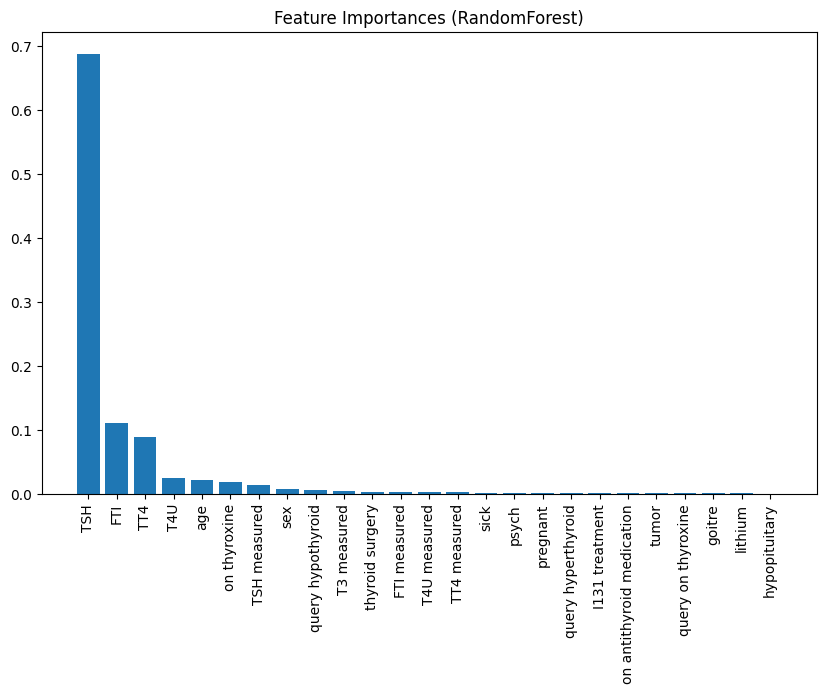

In [8]:
# ------------------------------
# STEP 8: FEATURE IMPORTANCES
# ------------------------------
import matplotlib.pyplot as plt

clf = pipeline.named_steps['clf']
importances = clf.feature_importances_

# Get feature names after preprocessing
feature_names = num_features + bin_features

idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[idx])
plt.xticks(range(len(importances)), np.array(feature_names)[idx], rotation=90)
plt.title("Feature Importances (RandomForest)")
plt.show()

giving model sample

In [9]:
import pandas as pd

sample = pd.DataFrame([{
    'age': 25,
    'sex': 0,
    'TSH': 1.58,
    'TT4': 82.56,
    'T4U': 0.9,
    'FTI': 120,
    'on thyroxine': 0,
    'query on thyroxine': 0,
    'on antithyroid medication': 0,
    'sick': 0,
    'pregnant': 0,
    'thyroid surgery': 0,
    'I131 treatment': 0,
    'query hypothyroid': 0,
    'query hyperthyroid': 0,
    'lithium': 0,
    'goitre': 0,
    'tumor': 0,
    'hypopituitary': 0,
    'psych': 0,
    'TSH measured': 1,
    'T3 measured': 0,
    'TT4 measured': 1,
    'T4U measured': 1,
    'FTI measured': 1
}])


pred = pipeline.predict(sample)
proba = pipeline.predict_proba(sample)

print("Predicted class:", pred[0])
print("Probabilities:", proba[0])

Predicted class: 0
Probabilities: [1. 0.]


Error percentage

In [10]:
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9973509933774835
